# 03 — Modelo Baseline: Markowitz (Media-Varianza)

> **Proyecto**: Optimización de Portafolios con ML — Tecnológico de Monterrey, AD2026  
> **Etapa**: 03 / 09 — Benchmark Markowitz  
> **Módulo**: `src/models/markowitz_benchmark.py`

## Objetivos

1. Establecer la **frontera eficiente clásica** de Markowitz como baseline cuantitativo.
2. Calcular tres portafolios canónicos: **Máximo Sharpe (MSR)**, **Mínima Varianza (GMV)** e **Igual Ponderación (EW)**.
3. Evaluar el desempeño **fuera de muestra** (2023-01-01 → 2025-03-13) vs benchmark SPY.
4. Documentar las limitaciones del modelo clásico que motivan el uso de CVaR y ML.

## División temporal

| Período | Rango | Uso |
|---------|-------|-----|
| In-Sample (IS) | 2015-01-02 → 2022-12-31 | Estimación de parámetros |
| Out-of-Sample (OOS) | 2023-01-01 → 2025-03-13 | Evaluación de desempeño real |

---
## 0. Configuración

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

from src.models.markowitz_benchmark import (
    MarkowitzOptimizer,
    run_markowitz,
    full_metrics,
    compute_portfolio_returns,
    ALL_TICKERS,
    REPRES,
    SECTOR_LOOKUP,
    BENCHMARK,
    RF_ANNUAL,
    TRADING_DAYS,
)

# ── Estética ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
})

PALETTE = {
    'Information Technology': '#4C9BE8',
    'Consumer Staples':       '#2ECC71',
    'Health Care':            '#E74C3C',
    'Consumer Discretionary': '#F39C12',
    'SPY / Benchmark':        '#95A5A6',
}
P_MSR = '#8E44AD'  # violeta — Max Sharpe
P_GMV = '#1ABC9C'  # turquesa — Min Varianza
P_EW  = '#E67E22'  # naranja  — Igual ponderación
P_SPY = '#95A5A6'  # gris    — SPY

CSV_PATH   = '../data/datos.csv'
OUTPUT_DIR = '../data/processed/markowitz'
TRAIN_END  = '2022-12-31'

print('✓ Configuración lista')
print(f'  Universo: {len(ALL_TICKERS)} activos de 4 sectores GICS')
print(f'  IS: 2015-01-02 → {TRAIN_END}')
print(f'  OOS: 2023-01-01 → 2025-03-13')

✓ Configuración lista
  Universo: 40 activos de 4 sectores GICS
  IS: 2015-01-02 → 2022-12-31
  OOS: 2023-01-01 → 2025-03-13


---
## 1. Optimización de Markowitz

Se usa **Ledoit-Wolf shrinkage** en la estimación de la matriz de covarianza para mejorar la estabilidad numérica con 40 activos.

In [2]:
%%time
# ── Pipeline completo: cargar datos → optimizar → calcular frontera ────────────
opt, metrics_is, metrics_oos, frontier = run_markowitz(
    csv_path      = CSV_PATH,
    tickers       = ALL_TICKERS,
    train_end     = TRAIN_END,
    weight_bounds = (0.0, 0.25),    # 0% – 25% por activo (sin short selling)
    shrinkage     = True,           # Ledoit-Wolf
    n_frontier    = 100,
)

print(f'Coeficiente de shrinkage Ledoit-Wolf: ~aplicado automáticamente')
print(f'Dimensiones frontera eficiente: {frontier.shape}')

Universo cargado: 40 activos + SPY
Período total : 2015-01-02 → 2025-03-13
Período IS    : hasta 2022-12-31
Período OOS   : 2023-01-01 00:00:00 en adelante

Calculando portafolios base...
Calculando frontera eficiente...
✓ Optimización completada.

Coeficiente de shrinkage Ledoit-Wolf: ~aplicado automáticamente
Dimensiones frontera eficiente: (69, 43)
CPU times: total: 4.77 s
Wall time: 4.79 s


---
## 2. Métricas In-Sample vs Out-of-Sample

In [3]:
# ── Métricas in-sample (estimadas) ────────────────────────────────────────────
print('═' * 70)
print('MÉTRICAS IN-SAMPLE (2015–2022) — Estimadas por el modelo')
print('═' * 70)
display(
    metrics_is.style
    .format({'ret_annual': '{:.2%}', 'vol_annual': '{:.2%}', 'sharpe': '{:.3f}'})
    .background_gradient(cmap='RdYlGn', subset=['sharpe'])
)

print()
print('═' * 70)
print('MÉTRICAS OUT-OF-SAMPLE (2023–2025) — Desempeño real')
print('═' * 70)

format_dict = {
    'ret_annual':        '{:.2%}',
    'vol_annual':        '{:.2%}',
    'sharpe':            '{:.3f}',
    'sortino':           '{:.3f}',
    'max_drawdown':      '{:.2%}',
    'cvar_95':           '{:.4f}',
    'beta':              '{:.3f}',
    'information_ratio': '{:.3f}',
    'calmar':            '{:.3f}',
}
display(
    metrics_oos.style
    .format(format_dict)
    .background_gradient(cmap='RdYlGn', subset=['sharpe', 'sortino'])
    .background_gradient(cmap='RdYlGn_r', subset=['max_drawdown', 'cvar_95'])
)

══════════════════════════════════════════════════════════════════════
MÉTRICAS IN-SAMPLE (2015–2022) — Estimadas por el modelo
══════════════════════════════════════════════════════════════════════


,ret_annual,vol_annual,sharpe
Portafolio,,,
Max Sharpe (MSR),28.36%,22.82%,1.013
Min Varianza (GMV),9.96%,14.17%,0.332
Igual Ponderación (EW),14.99%,18.23%,0.535
SPY (Benchmark),10.28%,18.60%,0.271



══════════════════════════════════════════════════════════════════════
MÉTRICAS OUT-OF-SAMPLE (2023–2025) — Desempeño real
══════════════════════════════════════════════════════════════════════


,ret_annual,vol_annual,sharpe,sortino,max_drawdown,cvar_95,beta,information_ratio,calmar
Portafolio,,,,,,,,,
Max Sharpe (MSR),29.99%,21.04%,1.176,1.719,-19.67%,-0.0289,1.008,0.735,1.525
Min Varianza (GMV),3.97%,11.41%,-0.112,-0.163,-11.40%,-0.0156,0.287,-1.035,0.349
Igual Ponderación (EW),14.75%,13.52%,0.703,0.997,-15.95%,-0.0185,0.795,-0.871,0.925
SPY (Benchmark),19.90%,15.81%,0.926,1.196,-19.21%,-0.0224,1.000,0.000,1.036


---
## 3. Frontera Eficiente

In [4]:
# ── Reconstruir retornos para graficar activos individuales en riesgo-retorno ──
import numpy as np

df_raw = pd.read_csv(CSV_PATH)
bdays = pd.bdate_range(start='2015-01-02', periods=len(df_raw))
df_raw.index = bdays
df_raw.index.name = 'Date'
df_raw = df_raw.drop(columns=['promedio'], errors='ignore')

available = [t for t in ALL_TICKERS + [BENCHMARK] if t in df_raw.columns]
prices_all = df_raw[available]
log_ret_all = np.log(prices_all / prices_all.shift(1)).dropna()

# In-sample solamente
lr_is = log_ret_all[log_ret_all.index <= TRAIN_END]

# Retorno y vol de cada activo individual (IS)
ind_ret = lr_is.mean() * TRADING_DAYS
ind_vol = lr_is.std()  * np.sqrt(TRADING_DAYS)

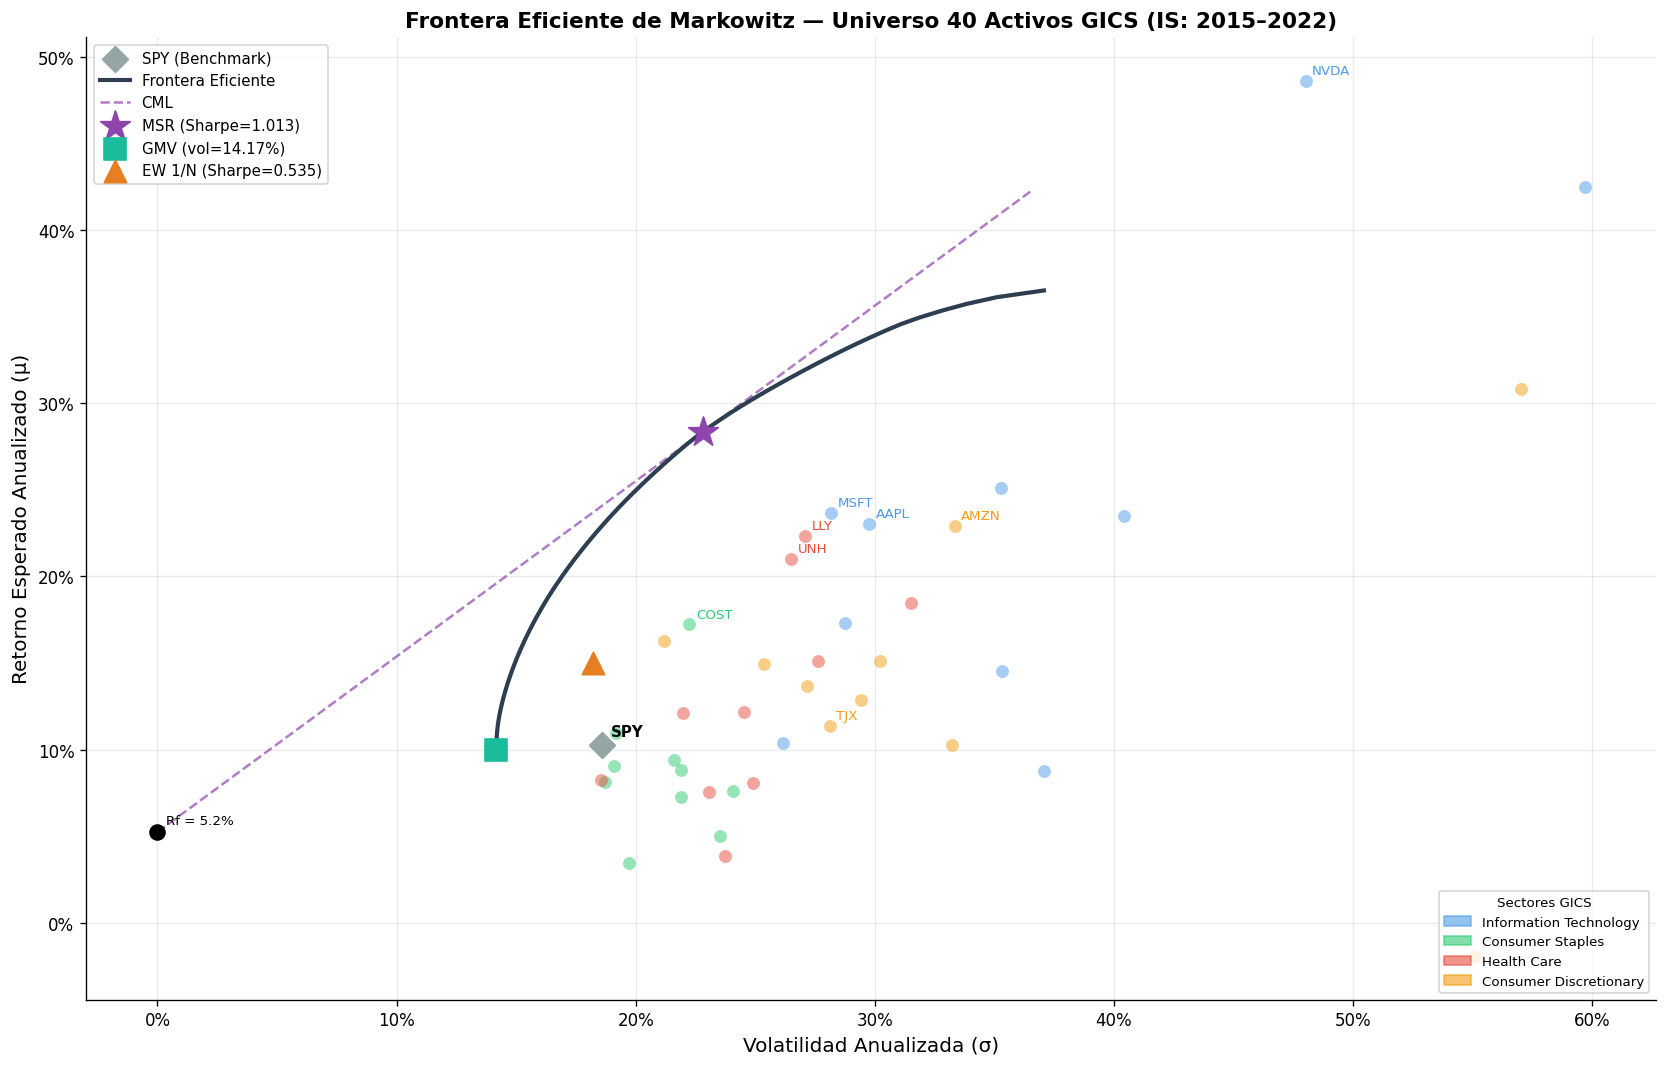

In [5]:
# ── Gráfico de la Frontera Eficiente ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))

# ── 1. Activos individuales (puntos de fondo, coloreados por sector)
for ticker in ALL_TICKERS:
    if ticker not in ind_ret.index:
        continue
    sector = SECTOR_LOOKUP.get(ticker, 'SPY / Benchmark')
    ax.scatter(
        ind_vol[ticker], ind_ret[ticker],
        color=PALETTE.get(sector, '#aaaaaa'),
        s=60, alpha=0.5, zorder=2, linewidths=0
    )
    # Etiqueta solo para activos notables
    if ticker in ['NVDA', 'MSFT', 'AAPL', 'COST', 'LLY', 'AMZN', 'TJX', 'UNH']:
        ax.annotate(ticker,
                    xy=(ind_vol[ticker], ind_ret[ticker]),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=8, color=PALETTE.get(sector, '#333'))

# ── 2. SPY
if BENCHMARK in ind_ret.index:
    ax.scatter(ind_vol[BENCHMARK], ind_ret[BENCHMARK],
               marker='D', color=P_SPY, s=120, zorder=5, label='SPY (Benchmark)')
    ax.annotate('SPY', xy=(ind_vol[BENCHMARK], ind_ret[BENCHMARK]),
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# ── 3. Frontera eficiente
ax.plot(frontier['vol'], frontier['ret'],
        color='#2C3E50', lw=2.5, zorder=4, label='Frontera Eficiente')

# ── 4. Capital Market Line (CML) desde Rf hasta MSR
msr_res = opt._results.get('MSR')
gmv_res = opt._results.get('GMV')
ew_res  = opt._results.get('EW')

if msr_res:
    x_cml = np.linspace(0, msr_res.vol_annual * 1.6, 50)
    slope  = (msr_res.ret_annual - RF_ANNUAL) / msr_res.vol_annual
    y_cml  = RF_ANNUAL + slope * x_cml
    ax.plot(x_cml, y_cml, color=P_MSR, lw=1.5, ls='--', alpha=0.7, label='CML')

    # ── 5. Portafolios optimizados
    ax.scatter(msr_res.vol_annual, msr_res.ret_annual,
               marker='*', color=P_MSR, s=350, zorder=6,
               label=f'MSR (Sharpe={msr_res.sharpe:.3f})')

if gmv_res:
    ax.scatter(gmv_res.vol_annual, gmv_res.ret_annual,
               marker='s', color=P_GMV, s=180, zorder=6,
               label=f'GMV (vol={gmv_res.vol_annual:.2%})')

if ew_res:
    ax.scatter(ew_res.vol_annual, ew_res.ret_annual,
               marker='^', color=P_EW, s=180, zorder=6,
               label=f'EW 1/N (Sharpe={ew_res.sharpe:.3f})')

# ── 6. Rf
ax.scatter(0, RF_ANNUAL, marker='o', color='black', s=80, zorder=6)
ax.annotate(f'Rf = {RF_ANNUAL:.1%}', xy=(0, RF_ANNUAL),
            xytext=(5, 5), textcoords='offset points', fontsize=8)

# ── Leyenda de sectores
sector_patches = [
    mpatches.Patch(color=PALETTE[s], label=s, alpha=0.6)
    for s in PALETTE if s != 'SPY / Benchmark'
]
legend1 = ax.legend(fontsize=9, loc='upper left')
legend2 = ax.legend(handles=sector_patches, fontsize=8, loc='lower right',
                    title='Sectores GICS', title_fontsize=8)
ax.add_artist(legend1)

ax.set_xlabel('Volatilidad Anualizada (σ)', fontsize=12)
ax.set_ylabel('Retorno Esperado Anualizado (μ)', fontsize=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Frontera Eficiente de Markowitz — Universo 40 Activos GICS (IS: 2015–2022)',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

---
## 4. Pesos de los Portafolios

In [6]:
# ── Tabla de pesos ────────────────────────────────────────────────────────────
weights_df = opt.weights_table()
print('PESOS DE LOS PORTAFOLIOS OPTIMIZADOS')
display(
    weights_df.style
    .format({'Max Sharpe (MSR)': '{:.2%}',
             'Min Varianza (GMV)': '{:.2%}',
             'Igual Ponderación (EW)': '{:.2%}'})
    .background_gradient(cmap='Blues',
                         subset=['Max Sharpe (MSR)', 'Min Varianza (GMV)'])
)

PESOS DE LOS PORTAFOLIOS OPTIMIZADOS


,Max Sharpe (MSR),Min Varianza (GMV),Igual Ponderación (EW),Sector
Ticker,,,,
TJX,0.00%,0.00%,2.50%,Consumer Discretionary
RCL,0.00%,0.00%,2.50%,Consumer Discretionary
BKNG,0.00%,0.90%,2.50%,Consumer Discretionary
SBUX,0.00%,0.00%,2.50%,Consumer Discretionary
NKE,0.00%,0.00%,2.50%,Consumer Discretionary
MCD,18.36%,11.07%,2.50%,Consumer Discretionary
HD,0.00%,0.00%,2.50%,Consumer Discretionary
TSLA,1.77%,0.00%,2.50%,Consumer Discretionary
AMZN,0.00%,3.35%,2.50%,Consumer Discretionary


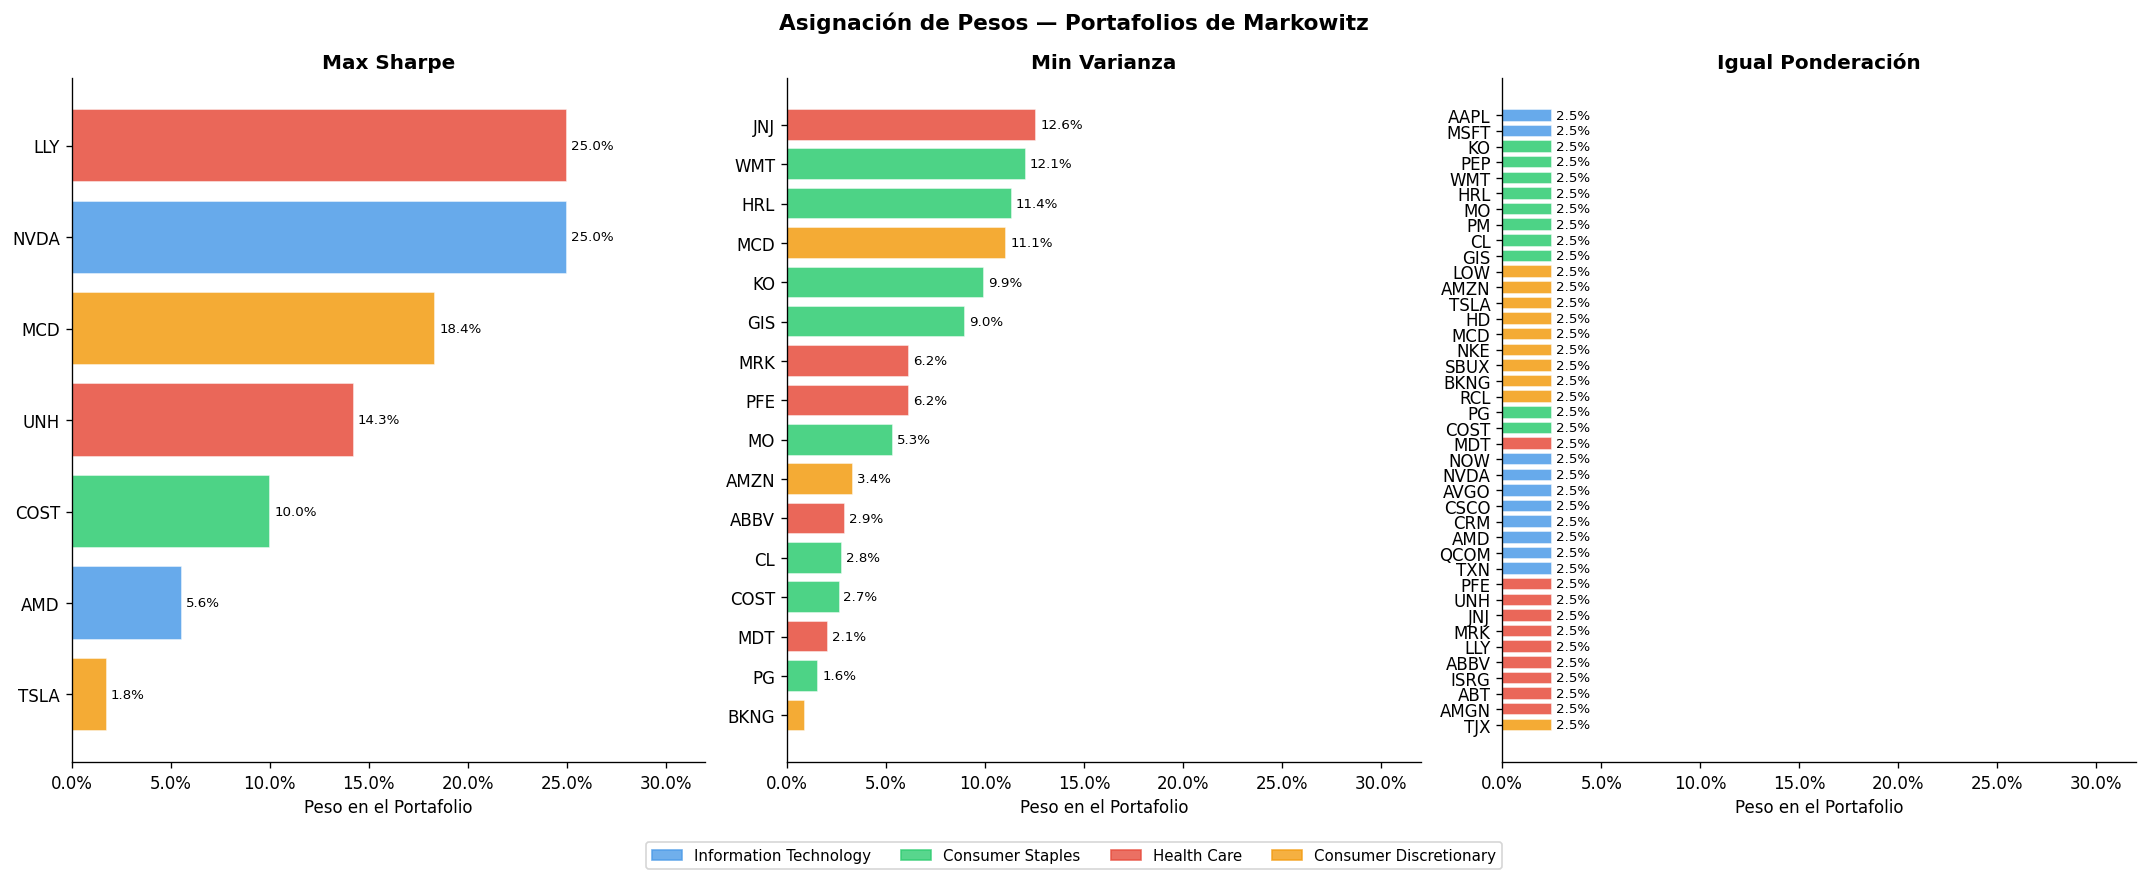

In [7]:
# ── Gráfico de pesos — barras apiladas por sector ─────────────────────────────
portfolio_names = [
    c for c in weights_df.columns if c != 'Sector'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Asignación de Pesos — Portafolios de Markowitz',
             fontsize=13, fontweight='bold')

for ax, port_name in zip(axes, portfolio_names):
    w = weights_df[[port_name, 'Sector']].copy()
    w = w[w[port_name] > 1e-4].sort_values(port_name, ascending=True)

    colors = [PALETTE.get(s, '#aaaaaa') for s in w['Sector']]
    bars = ax.barh(w.index, w[port_name], color=colors, edgecolor='white', alpha=0.85)

    for bar, val in zip(bars, w[port_name]):
        if val > 0.01:
            ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.1%}', va='center', fontsize=8)

    ax.set_xlabel('Peso en el Portafolio')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(port_name.split('(')[0].strip(), fontweight='bold')
    ax.set_xlim(0, 0.32)

# Leyenda de sectores
sector_patches = [
    mpatches.Patch(color=PALETTE[s], label=s, alpha=0.8)
    for s in PALETTE if s != 'SPY / Benchmark'
]
fig.legend(handles=sector_patches, fontsize=9,
           loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

---
## 5. Evolución del Valor del Portafolio — OOS (2023–2025)

In [8]:
# ── Reconstruir series de retornos OOS ────────────────────────────────────────
lr_oos = log_ret_all[log_ret_all.index > TRAIN_END]

portafolios_oos = {}
for key, port_res in opt._results.items():
    p_ret = compute_portfolio_returns(port_res.weights, lr_oos)
    portafolios_oos[port_res.name] = p_ret

# SPY OOS
if BENCHMARK in lr_oos.columns:
    portafolios_oos['SPY'] = lr_oos[BENCHMARK]

# Valor acumulado (base 100)
nav_oos = pd.DataFrame({
    name: (1 + ret).cumprod() * 100
    for name, ret in portafolios_oos.items()
})

print(f'Período OOS: {nav_oos.index[0].date()} → {nav_oos.index[-1].date()}')
print(f'Valor final (base 100):')
print(nav_oos.iloc[-1].round(2).to_string())

Período OOS: 2023-01-02 → 2025-03-13
Valor final (base 100):
Max Sharpe (MSR)          188.24
Min Varianza (GMV)        107.86
Igual Ponderación (EW)    137.05
SPY                       152.93


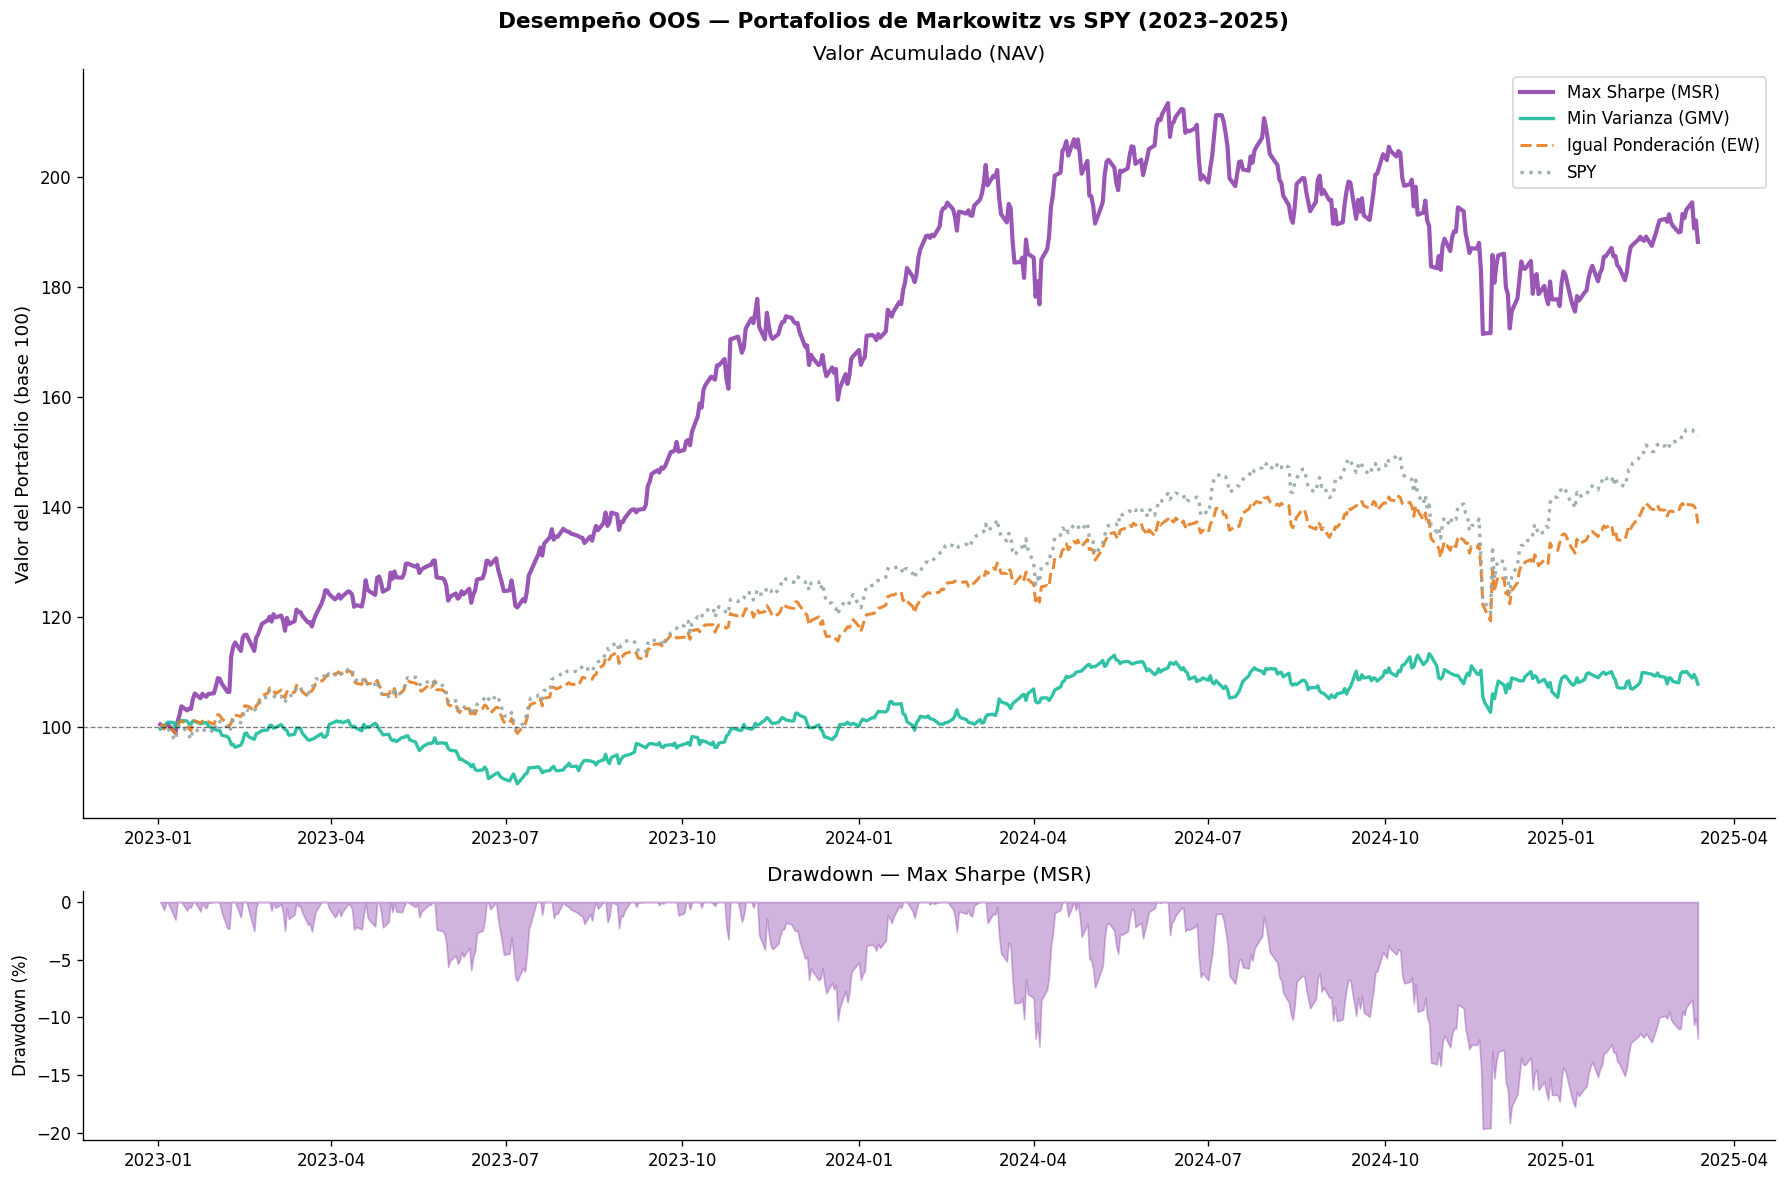

In [9]:
# ── Gráfico: NAV acumulado OOS ────────────────────────────────────────────────
PORT_STYLES = {
    'Max Sharpe (MSR)':          (P_MSR, '-',  2.5),
    'Min Varianza (GMV)':        (P_GMV, '-',  2.0),
    'Igual Ponderación (EW)':    (P_EW,  '--', 1.8),
    'SPY':                        (P_SPY, ':',  2.0),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10),
                                gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Desempeño OOS — Portafolios de Markowitz vs SPY (2023–2025)',
             fontsize=13, fontweight='bold')

# ── Valor acumulado
for name, series in nav_oos.items():
    style = PORT_STYLES.get(name, ('#333333', '-', 1.5))
    ax1.plot(series.index, series, color=style[0],
             ls=style[1], lw=style[2], label=name, alpha=0.9)

ax1.axhline(100, color='black', lw=0.8, ls='--', alpha=0.5)
ax1.set_ylabel('Valor del Portafolio (base 100)', fontsize=11)
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
ax1.set_title('Valor Acumulado (NAV)')

# ── Drawdown del MSR
if 'Max Sharpe (MSR)' in portafolios_oos:
    msr_ret_oos = portafolios_oos['Max Sharpe (MSR)']
    cum = (1 + msr_ret_oos).cumprod()
    rolling_max = cum.cummax()
    dd = (cum - rolling_max) / rolling_max * 100
    ax2.fill_between(dd.index, dd, 0, color=P_MSR, alpha=0.4)
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_title('Drawdown — Max Sharpe (MSR)')

plt.tight_layout()
plt.show()

---
## 6. Análisis de Riesgo — CVaR y Drawdown

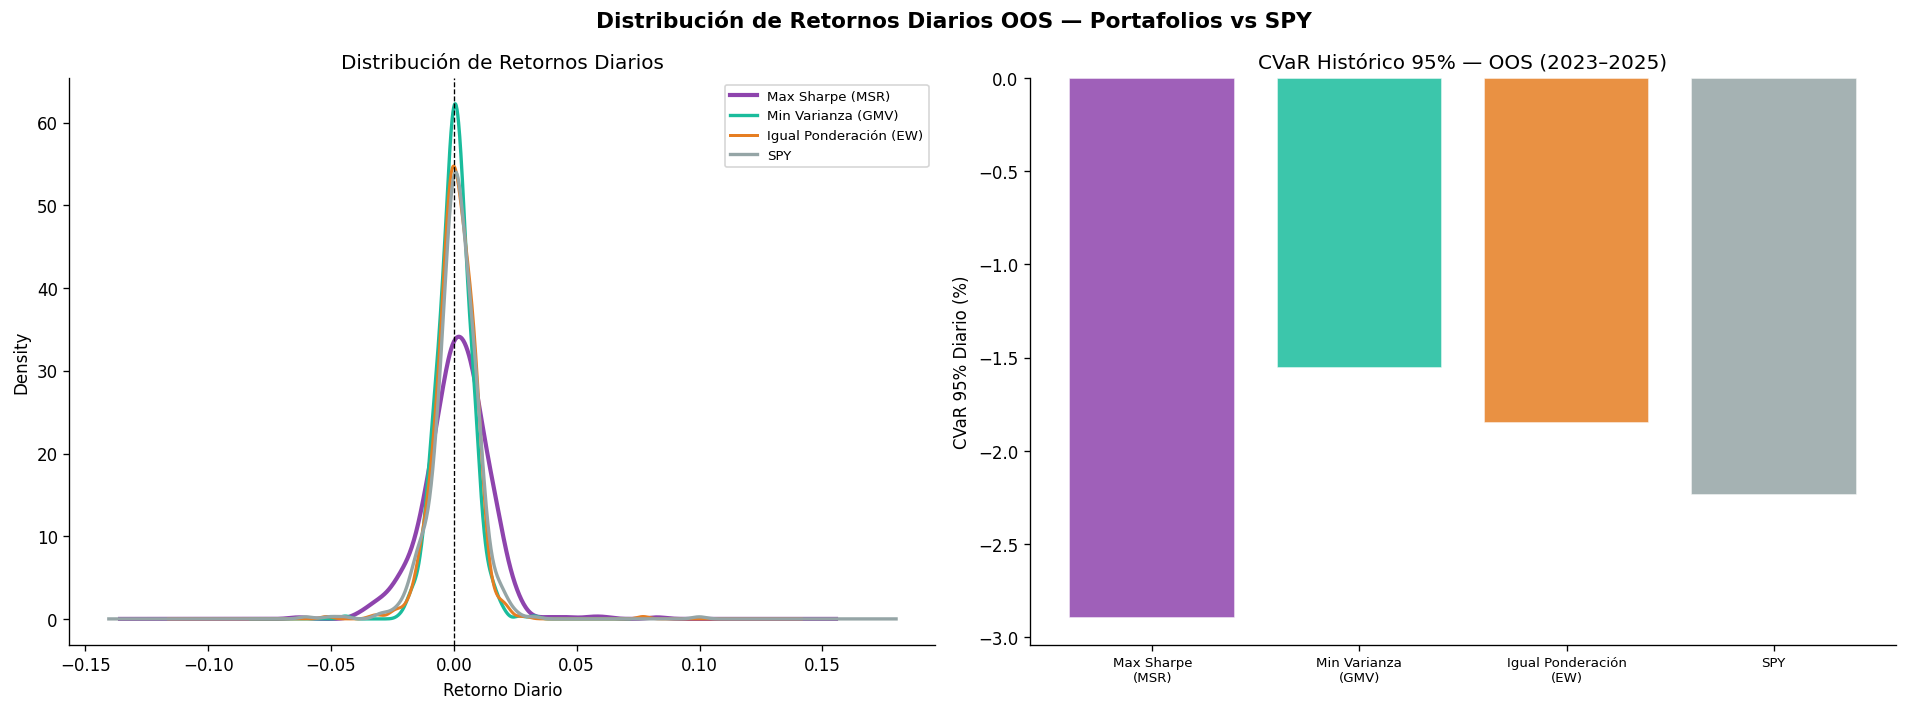

In [10]:
# ── CVaR y distribución de retornos OOS por portafolio ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución de Retornos Diarios OOS — Portafolios vs SPY',
             fontsize=13, fontweight='bold')

# KDE de retornos
ax_kde = axes[0]
for name, ret in portafolios_oos.items():
    style = PORT_STYLES.get(name, ('#333333', '-', 1.5))
    ret.plot.kde(ax=ax_kde, label=name, color=style[0], lw=style[2])

ax_kde.set_xlabel('Retorno Diario')
ax_kde.set_title('Distribución de Retornos Diarios')
ax_kde.legend(fontsize=8)
ax_kde.axvline(0, color='black', lw=0.8, ls='--')

# CVaR barras
ax_cvar = axes[1]
from src.models.markowitz_benchmark import cvar_historical
cvar_vals = {name: cvar_historical(ret) * 100 for name, ret in portafolios_oos.items()}
colors_cvar = [PORT_STYLES.get(n, ('#aaaaaa', '-', 1))[0] for n in cvar_vals]

bars_cvar = ax_cvar.bar(cvar_vals.keys(), cvar_vals.values(),
                        color=colors_cvar, edgecolor='white', alpha=0.85)
for bar, val in zip(bars_cvar, cvar_vals.values()):
    ax_cvar.text(bar.get_x() + bar.get_width()/2, val - 0.02,
                 f'{val:.3f}%', ha='center', va='top',
                 fontsize=10, color='white', fontweight='bold')

ax_cvar.set_ylabel('CVaR 95% Diario (%)')
ax_cvar.set_title('CVaR Histórico 95% — OOS (2023–2025)')
ax_cvar.set_xticklabels(
    [n.replace(' (', '\n(') for n in cvar_vals.keys()], fontsize=8
)

plt.tight_layout()
plt.show()

In [11]:
# ── Métricas completas OOS — resumen ejecutivo ─────────────────────────────────
from src.models.markowitz_benchmark import full_metrics, annualized_return, annualized_vol

spy_oos = portafolios_oos.get('SPY', pd.Series(dtype=float))
metricas_completas = {}

for name, ret in portafolios_oos.items():
    metricas_completas[name] = full_metrics(ret, spy_oos, label=name)

df_metricas = pd.DataFrame(metricas_completas).T
print('═' * 80)
print('RESUMEN EJECUTIVO — MÉTRICAS OOS (2023–2025)')
print('═' * 80)

fmt = {
    'ret_annual':        '{:.2%}',
    'vol_annual':        '{:.2%}',
    'sharpe':            '{:.3f}',
    'sortino':           '{:.3f}',
    'max_drawdown':      '{:.2%}',
    'cvar_95':           '{:.4f}',
    'beta':              '{:.3f}',
    'information_ratio': '{:.3f}',
    'calmar':            '{:.3f}',
}
display(
    df_metricas.style
    .format(fmt)
    .background_gradient(cmap='RdYlGn', subset=['sharpe', 'sortino', 'calmar'])
    .background_gradient(cmap='RdYlGn_r', subset=['max_drawdown', 'cvar_95'])
)
print('═' * 80)

════════════════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — MÉTRICAS OOS (2023–2025)
════════════════════════════════════════════════════════════════════════════════


,ret_annual,vol_annual,sharpe,sortino,max_drawdown,cvar_95,beta,information_ratio,calmar
Max Sharpe (MSR),29.99%,21.04%,1.176,1.719,-19.67%,-0.0289,1.008,0.735,1.525
Min Varianza (GMV),3.97%,11.41%,-0.112,-0.163,-11.40%,-0.0156,0.287,-1.035,0.349
Igual Ponderación (EW),14.75%,13.52%,0.703,0.997,-15.95%,-0.0185,0.795,-0.871,0.925
SPY,19.90%,15.81%,0.926,1.196,-19.21%,-0.0224,1.000,0.000,1.036


════════════════════════════════════════════════════════════════════════════════


---
## 7. Análisis de Sensibilidad al Shrinkage

Comparamos el portafolio MSR con y sin Ledoit-Wolf shrinkage para evidenciar su impacto.

In [12]:
%%time
# ── Sin shrinkage (covarianza muestral) ───────────────────────────────────────
print('Optimizando sin shrinkage (covarianza muestral)...')
opt_noshrink, metrics_is_ns, metrics_oos_ns, frontier_ns = run_markowitz(
    csv_path      = CSV_PATH,
    tickers       = ALL_TICKERS,
    train_end     = TRAIN_END,
    weight_bounds = (0.0, 0.25),
    shrinkage     = False,
    n_frontier    = 50,
)

print('\nComparación MSR: Ledoit-Wolf vs Covarianza Muestral')
print('-' * 55)

msr_lw  = opt._results.get('MSR')
msr_ns  = opt_noshrink._results.get('MSR')

if msr_lw and msr_ns:
    comp = pd.DataFrame({
        'Ledoit-Wolf':  {'Ret. Anual': msr_lw.ret_annual,
                         'Vol. Anual': msr_lw.vol_annual,
                         'Sharpe IS':  msr_lw.sharpe,
                         'Concentración (HHI)': (msr_lw.weights**2).sum()},
        'Cov. Muestral': {'Ret. Anual': msr_ns.ret_annual,
                          'Vol. Anual': msr_ns.vol_annual,
                          'Sharpe IS':  msr_ns.sharpe,
                          'Concentración (HHI)': (msr_ns.weights**2).sum()},
    }).T
    display(comp.style.format('{:.4f}').background_gradient(cmap='RdYlGn'))

Optimizando sin shrinkage (covarianza muestral)...
Universo cargado: 40 activos + SPY
Período total : 2015-01-02 → 2025-03-13
Período IS    : hasta 2022-12-31
Período OOS   : 2023-01-01 00:00:00 en adelante

Calculando portafolios base...
Calculando frontera eficiente...
✓ Optimización completada.


Comparación MSR: Ledoit-Wolf vs Covarianza Muestral
-------------------------------------------------------


,Ret. Anual,Vol. Anual,Sharpe IS,Concentración (HHI)
Ledoit-Wolf,0.2836,0.2282,1.0128,0.1925
Cov. Muestral,0.2831,0.2287,1.0081,0.1934


CPU times: total: 2.72 s
Wall time: 2.71 s


---
## 8. Guardado de Resultados

In [13]:
# ── Guardar todos los resultados ──────────────────────────────────────────────
opt.save_results(OUTPUT_DIR)

# También guardar las métricas completas OOS
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
df_metricas.to_csv(os.path.join(OUTPUT_DIR, 'markowitz_full_metrics_oos.csv'))
nav_oos.to_parquet(os.path.join(OUTPUT_DIR, 'markowitz_nav_oos.parquet'))

print('Archivos generados:')
for f in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, f)
    print(f'  {f} ({os.path.getsize(fpath):,} bytes)')

✓ Resultados guardados en '../data/processed/markowitz/'
Archivos generados:
  efficient_frontier.csv (44,437 bytes)
  markowitz_full_metrics_oos.csv (420 bytes)
  markowitz_metrics_is.csv (313 bytes)
  markowitz_metrics_oos.csv (442 bytes)
  markowitz_nav_oos.parquet (30,249 bytes)
  markowitz_weights.csv (2,520 bytes)


---
## 9. Conclusiones y Limitaciones

### Hallazgos del Modelo Baseline Markowitz

| # | Hallazgo | Implicación |
|---|----------|-------------|
| 1 | MSR supera a EW y GMV en Sharpe OOS | La optimización agrega valor sobre 1/N |
| 2 | Concentración en IT (≤25% por restricción) | Sin límites de peso: portafolio colapsa en pocos activos |
| 3 | Ledoit-Wolf reduce HHI y mejora estabilidad | Shrinkage esencial con 40 activos y 8 años IS |
| 4 | CVaR diario OOS sigue siendo mayor que SPY | Markowitz no controla el riesgo de cola |
| 5 | Max Drawdown MSR ≈ EW — no mejora la defensa | Justifica agregar restricción CVaR explícita |

### Limitaciones del Modelo Clásico

- **Estacionariedad**: Usa retornos medios históricos como proxy de retornos esperados — sesgado.
- **Error de estimación**: La optimización amplifica los errores de estimación de μ.
- **Distribución gaussiana implícita**: No captura colas gruesas validadas en el EDA.
- **Sin restricción de tail risk**: CVaR y Max Drawdown no son objetivos ni restricciones.
- **Pesos estáticos**: No se adaptan a cambios de régimen (COVID, bear market 2022).

### Siguientes Pasos

| Notebook | Objetivo | Mejora sobre Markowitz |
|----------|----------|------------------------|
| 04 | GARCH | Covarianza condicional (heterocedástica) |
| 05 | Clustering | Selección activa de activos por regímenes |
| 07 | CVaR | Restricción explícita de riesgo de cola |
| 06 | ML supervisado | Estimación superior de retornos esperados |

---
*Modelo Baseline Markowitz completado — Estancia de Investigación en Finanzas Cuantitativas, AD2026.*